In [ ]:
import librosa
import numpy as np

# 1. Load the audio file (convert to mono, keep original sample rate)
y, sr = librosa.load("5afc6a14-a9d8-45f8-b31d-c79dd87cc8c6-1430757039803-1.7-m-48-bu.wav", sr=None, mono=True)

# 2. Extract MFCCs (20 coefficients is common)
mfccs = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=20,
    n_fft=2048,
    hop_length=512
)

# 3. Take mean over time (frames) → fixed-length feature vector

mfcc_scaled = np.mean(mfccs, axis=1)

print("MFCC shape (coefficients x frames):", mfccs.shape)

print("Final feature vector shape:", mfcc_scaled.shape)
print("MFCC feature vector:", mfcc_scaled)


In [ ]:
# 4. Delta (1st derivative)
delta_mfcc = librosa.feature.delta(mfccs)

# 5. Delta-Delta (2nd derivative)
delta2_mfcc = librosa.feature.delta(mfccs, order=2)

# 6. Mean pooling
mfcc_mean = np.mean(mfccs, axis=1)
delta_mean = np.mean(delta_mfcc, axis=1)
delta2_mean = np.mean(delta2_mfcc, axis=1)

# 7. Combine all features
final_feature_vector = np.hstack([
    mfcc_mean,
    delta_mean,
    delta2_mean
])

print("Final feature vector shape:", final_feature_vector.shape)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
final_feature_vector = scaler.fit_transform(
    final_feature_vector.reshape(1, -1)
).flatten()


In [39]:
import os
import librosa
import numpy as np

DATASET_PATH = "data/raw"

CLASSES = [
    "belly_pain",
    "burping",
    "discomfort",
    "hungry",
    "tired"
]


In [43]:
def extract_features(filepath):
    y, sr = librosa.load(filepath, sr=None, mono=True)

    mfccs = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=30,
        n_fft=2048,
        hop_length=512
    )

    delta = librosa.feature.delta(mfccs)
    delta2 = librosa.feature.delta(mfccs, order=2)

    feature_vector = np.hstack([
        np.mean(mfccs, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta2, axis=1),
        np.std(mfccs,axis=1),
        np.std(delta,axis=1),
        np.std(delta2,axis=1)



    ])

    return feature_vector


In [44]:
X = []
y = []

for label, class_name in enumerate(CLASSES):
    class_folder = os.path.join(DATASET_PATH, class_name)

    for file in os.listdir(class_folder):
        if file.endswith(".wav"):
            filepath = os.path.join(class_folder, file)

            features = extract_features(filepath)

            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # (num_samples, 60)
print("y shape:", y.shape)  # (num_samples,)


X shape: (457, 180)
y shape: (457,)


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)


In [ ]:
model.fit(X_train, y_train)


In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test, y_pred, target_names=CLASSES, output_dict=True
)

df_report = pd.DataFrame(report)
print(df_report)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [54]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95,random_state=42)

X_train_pca = pca.fit_transform(X)
#X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X.shape[1])
print("Reduced features:", X_train_pca.shape[1])


Original features: 180
Reduced features: 89


In [ ]:
!pip install imbalanced-learn


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_final, y_train_final = smote.fit_resample(X_train_pca, y_train)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_final, y_train_final)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_pca)

print(classification_report(y_test, y_pred, target_names=CLASSES))
print(confusion_matrix(y_test, y_pred))


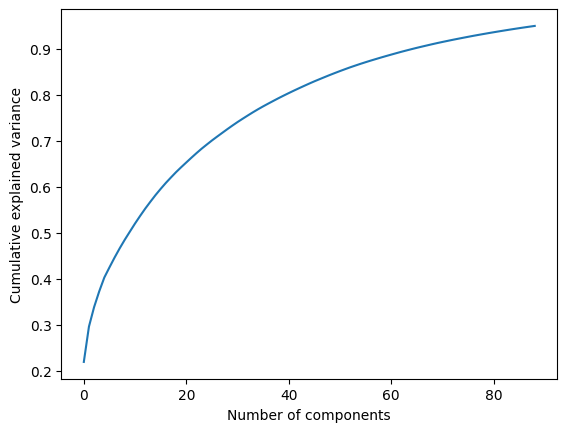

In [47]:
import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# If you already have PCA features
# X_train_pca shape → (samples, components)

plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    X_train_pca[:, 0],   # PC1
    X_train_pca[:, 1],   # PC2
    c=y,
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot (PC1 vs PC2)")

plt.colorbar(scatter, label="Class Label")
plt.grid(True)
plt.show()


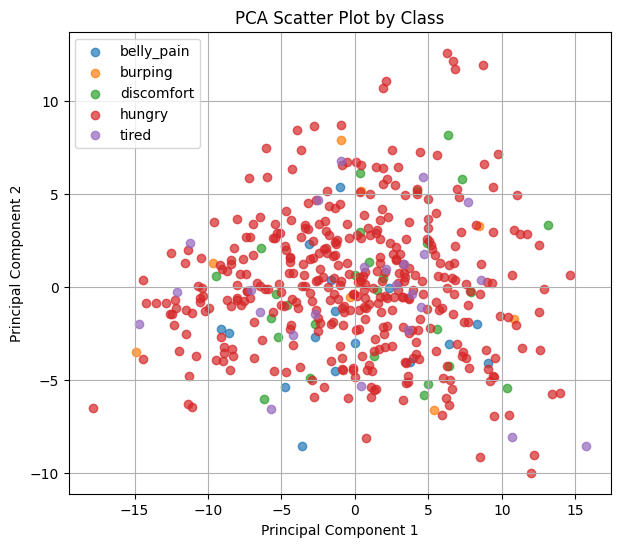

In [48]:
plt.figure(figsize=(7, 6))

for label, class_name in enumerate(CLASSES):
    idx = np.where(y == label)
    plt.scatter(
        X_train_pca[idx, 0],
        X_train_pca[idx, 1],
        label=class_name,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot by Class")
plt.legend()
plt.grid(True)
plt.show()
